# Crypto FactorManager 使用指南

统一入口，三类服务：
- **Research** — 因子研究与评估
- **Access** — 已入库因子的访问与查询
- **Manage** — 因子入库与管理

数据源：`binance_perp_1m.h5` (Binance USDT 永续合约 1 分钟 K 线)

默认回测：8h 调仓 (`perp_8h`)，可选 4h / 1d

## 0. 环境准备

In [1]:
import sys
sys.path.insert(0, "/root/crypto-research/common")
sys.path.insert(0, "/root/crypto-research")

## 1. 初始化

In [2]:
from factor_system.factor_hub.main import FactorManager

# 默认配置:
#   h5_path  = /root/crypto-research/common/data/raw/h5/binance_perp_1m.h5
#   base_dir = /root/crypto-research/common/factor_base
# fm = FactorManager()

# 自定义路径:
fm = FactorManager(
    h5_path="/root/crypto-research/common/data/raw/h5/bybit_linear_1m_unified_gp_research.h5",
    base_dir="/root/crypto-research/common/factor_base",
)

## 2. 数据层快速查看

`DataProvider` 可以直接使用，了解数据范围和可用字段。

In [3]:
dp = fm.dp

print("可用字段:", dp.list_datas())
print("时间范围:", dp.get_time_range())
print("标的数量:", len(dp.symbols))
print("标的示例:", dp.symbols[:10])

可用字段: ['close', 'closes', 'dollar_volume', 'funding', 'high', 'highs', 'index_close', 'listed_mask', 'low', 'lows', 'mark_close', 'open', 'open_interest', 'opens', 'premium_close', 'returns_1m', 'standards', 'tradable_mask', 'tradables', 'turnover', 'turnovers', 'universe_liquid', 'universe_major', 'universe_meme', 'volume', 'volumes', 'xbinance_quote_volume', 'xbinance_taker_buy_quote_volume', 'xbinance_taker_buy_volume', 'xbinance_trade_count']
时间范围: (Timestamp('2022-01-01 00:00:00'), Timestamp('2026-08-12 23:59:00'))
标的数量: 539
标的示例: ['0GUSDT', '1000000BABYDOGEUSDT', '1000000CHEEMSUSDT', '1000000MOGUSDT', '10000QUBICUSDT', '10000SATSUSDT', '1000BONKUSDT', '1000BTTUSDT', '1000CATUSDT', '1000FLOKIUSDT']


In [6]:
import h5py

# 自动获取你当前数据层底层的 H5 文件路径
h5_path = fm.research.simulator.value_engine.dp.h5_path

with h5py.File(h5_path, "r") as f:
    print("=== 你当前 H5 数据库中支持的所有数据字段 ===")
    print(list(f.keys()))

=== 你当前 H5 数据库中支持的所有数据字段 ===
['close', 'high', 'listed_mask', 'low', 'open', 'symbols', 'timestamp', 'tradable_mask', 'turnover', 'volume']


## 3. Research — 因子研究

### 3.1 evaluate — 单因子评估

支持多种输入：
- `.py` 文件路径
- `DataFrame` (因子值矩阵)
- `dict` (spec)
- `str` (formula)

关键参数：

| 参数 | 说明 | 默认值 |
|------|------|--------|
| `profile_id` | 回测配置 | `"perp_8h"` |
| `params` | `{"start","end","lookback_days","cost"}` | `lookback_days=365` |
| `plot` | 是否绘图 | `True` |
| `prod_corr` | 与库内因子相关性检查 | `False` |

#### 3.1.1 从 .py 文件评估

calc factor value time:  30.02540973946452 sec
calc factor result time:  8.711092811077833 sec
calc factor performance time:  0.009610864333808422 sec


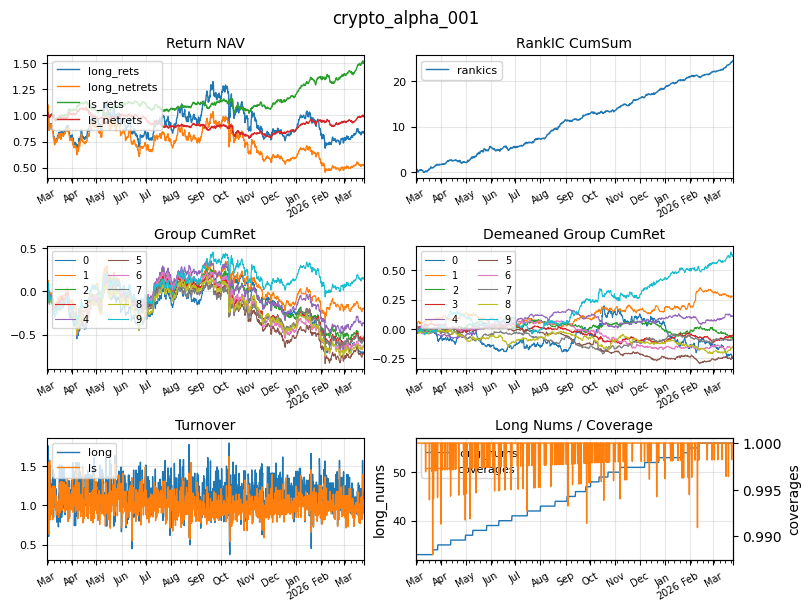

In [ ]:
# 评估示例因子（默认 lookback 365 天、8h 调仓）
# 这里演示显式指定区间；如果不传 params，则默认回看最近 365 天。
alpha_path = "/root/crypto-research/common/factor_system/how_to_use/alphas/crypto_alpha_001.py"
result = fm.evaluate(alpha_path,profile_id="perp_8h",plot=True,params={"start":"2025-03-01","end":"2026-03-25"})

In [ ]:
# 查看返回结构
print("返回 keys:", list(result.keys()))
print()

# factor_value: 因子值矩阵 (分钟频)
print("factor_value shape:", result["factor_value"].shape)
print("factor_value 时间范围:", result["factor_value"].index[0], "->", result["factor_value"].index[-1])
print()

# factor_performance: 回测绩效指标
perf = result["factor_performance"]["raw"]
for k, v in perf.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

返回 keys: ['id', 'factor_value', 'factor_result', 'factor_performance']

factor_value shape: (561601, 570)
factor_value 时间范围: 2025-02-28 00:00:00 -> 2026-03-25 00:00:00

  long_ret: -0.1520
  long_ir: -0.1955
  long_maxdd: 0.4803
  long_netret: -0.4515
  long_netir: -0.5805
  long_netmaxdd: 0.5834
  ls_ret: 0.4607
  ls_ir: 1.9890
  ls_maxdd: 0.1216
  ls_netret: -0.0106
  ls_netir: -0.0456
  ls_netmaxdd: 0.2719
  rankic: 0.0210
  rankicir: 7.2869
  long_turnover: 1.1360
  ls_turnover: 1.0167
  long_num: 45.4803
  coverage: 0.9995


#### 3.1.2 指定时间窗口

In [ ]:
result = fm.evaluate(
    alpha_path,
    params={"start": "2026-03-01", "end": "2026-03-15"},
    plot=False,
)
print("perf:", result["factor_performance"]["raw"])

calc factor value time:  1.042084583081305 sec
calc factor result time:  0.2640626132488251 sec
calc factor performance time:  0.0023291027173399925 sec
perf: {'long_ret': np.float64(4.08269116224791), 'long_ir': np.float64(8.851627605689114), 'long_maxdd': np.float64(0.042918087555080864), 'long_netret': np.float64(2.331921289491403), 'long_netir': np.float64(5.053929489153405), 'long_netmaxdd': np.float64(0.04731636755107416), 'ls_ret': np.float64(1.1131795717843773), 'ls_ir': np.float64(7.054884118095143), 'ls_maxdd': np.float64(0.02652489471646191), 'ls_netret': np.float64(0.45060056138107774), 'ls_netir': np.float64(2.855917117558156), 'ls_netmaxdd': np.float64(0.031008103367473838), 'rankic': np.float64(0.020498194716704513), 'rankicir': np.float64(10.818444789986804), 'long_turnover': np.float64(1.1029900332225915), 'ls_turnover': np.float64(0.9821428571428574), 'long_num': np.float64(56.0), 'coverage': np.float64(0.9998746686364282)}


#### 3.1.3 不同回测 profile

可选 profile:

| profile_id | 信号频率 | periods_per_year | 说明 |
|------------|---------|-----------------|------|
| `perp_8h` | 8h | 1095 | 默认，每 8 小时调仓 |
| `perp_4h` | 4h | 2190 | 每 4 小时调仓 |
| `perp_1d` | 1D | 365 | 每天调仓 |

In [ ]:
# 4h 调仓
result_4h = fm.evaluate(alpha_path, profile_id="perp_4h", plot=False)
print("4h perf:", result_4h["factor_performance"]["raw"])

# 1d 调仓
result_1d = fm.evaluate(alpha_path, profile_id="perp_1d", plot=False)
print("1d perf:", result_1d["factor_performance"]["raw"])

calc factor value time:  2.0990708274766803 sec
calc factor result time:  0.554056441411376 sec
calc factor performance time:  0.0030174506828188896 sec
4h perf: {'long_ret': np.float64(1.0230837080080843), 'long_ir': np.float64(2.5251377583805295), 'long_maxdd': np.float64(0.08649616451704967), 'long_netret': np.float64(0.09822082586422343), 'long_netir': np.float64(0.24238044351229127), 'long_netmaxdd': np.float64(0.09617616540810991), 'ls_ret': np.float64(1.45138400786995), 'ls_ir': np.float64(7.983890057323737), 'ls_maxdd': np.float64(0.022144145302475327), 'ls_netret': np.float64(0.44025109776721383), 'ls_netir': np.float64(2.420656301663009), 'ls_netmaxdd': np.float64(0.030882568863461968), 'rankic': np.float64(0.018519747590067852), 'rankicir': np.float64(12.089430350930769), 'long_turnover': np.float64(0.7971158008658008), 'ls_turnover': np.float64(0.6940241702741703), 'long_num': np.float64(55.99444444444445), 'coverage': np.float64(0.9997214024043906)}
calc factor value time:

#### 3.1.4 从 DataFrame 评估

In [ ]:
import numpy as np

# 自己构造因子值矩阵（1分钟频，index=DatetimeIndex, columns=symbols）
close = dp.get_single_data("close", start="2026-03-20", end="2026-03-25")
my_factor = close.pct_change(60, fill_method=None).rolling(120).mean()

result = fm.evaluate(my_factor, plot=False)
print("perf:", result["factor_performance"]["raw"])

calc factor result time:  0.10520977526903152 sec
calc factor performance time:  0.002482553943991661 sec
perf: {'long_ret': np.float64(-0.7201042963024525), 'long_ir': np.float64(-1.4180035519971699), 'long_maxdd': np.float64(0.0554174613288968), 'long_netret': np.float64(-0.8426347371682911), 'long_netir': np.float64(-1.658841728885098), 'long_netmaxdd': np.float64(0.05941287240651827), 'ls_ret': np.float64(-0.5522202603105901), 'ls_ir': np.float64(-1.5527235308575966), 'ls_maxdd': np.float64(0.038221000983955866), 'ls_netret': np.float64(-0.7511856130739679), 'ls_netir': np.float64(-2.1102860564260535), 'ls_netmaxdd': np.float64(0.04227714003624716), 'rankic': np.float64(-0.040919718315412475), 'rankicir': np.float64(-4.229200104202731), 'long_turnover': np.float64(1.5), 'ls_turnover': np.float64(1.53125), 'long_num': np.float64(1.75), 'coverage': np.float64(0.02238364596951198)}


#### 3.1.5 从 formula 评估

formula 引用 `data_needed` 中的字段名，使用 `quant_lib` 中的算子。

In [ ]:
result = fm.evaluate("-returns_1m", plot=False)
print("perf:", result["factor_performance"]["raw"])

calc factor value time:  0.6102961879223585 sec
calc factor result time:  0.4862358709797263 sec
calc factor performance time:  0.002492588944733143 sec
perf: {'long_ret': np.float64(-0.5337245391709289), 'long_ir': np.float64(-1.1266987756896052), 'long_maxdd': np.float64(0.17120383902090497), 'long_netret': np.float64(-0.750206888480507), 'long_netir': np.float64(-1.5837878569308377), 'long_netmaxdd': np.float64(0.19380191999114604), 'ls_ret': np.float64(0.12979691006249916), 'ls_ir': np.float64(0.7220068407011352), 'ls_maxdd': np.float64(0.06516594106827611), 'ls_netret': np.float64(-0.3983292464692334), 'ls_netir': np.float64(-2.2162779542633113), 'ls_netmaxdd': np.float64(0.07877661082240017), 'rankic': np.float64(0.020689743980498696), 'rankicir': np.float64(8.072807383542298), 'long_turnover': np.float64(1.6268269131392865), 'ls_turnover': np.float64(1.6437578168763909), 'long_num': np.float64(48.888888888888886), 'coverage': np.float64(1.0)}


### 3.2 evaluate_batch — 批量因子评估

支持：
- 文件夹路径（批量 `.py` 文件）
- `list[str]` (formula 列表)
- `dict[str, DataFrame]` (因子值字典)

返回 `(perf_df, corr_df)` 或 `perf_df`（取决于 `self_corr` 参数）。

In [ ]:
# 批量评估文件夹
alphas_dir = "/root/crypto-research/common/factor_system/how_to_use/alphas"
perf_df = fm.evaluate_batch(alphas_dir)
perf_df

evaluate factor: /root/crypto-research/common/factor_system/how_to_use/alphas/crypto_alpha_001.py
calc factor value time:  2.076785109937191 sec
calc factor result time:  0.5403171358630061 sec
calc factor performance time:  0.002541065216064453 sec


,long_ret,long_ir,long_maxdd,long_netret,long_netir,long_netmaxdd,ls_ret,ls_ir,ls_maxdd,ls_netret,ls_netir,ls_netmaxdd,rankic,rankicir,long_turnover,ls_turnover,long_num,coverage
id,,,,,,,,,,,,,,,,,,
crypto_alpha_001,1.602189,3.4027,0.113217,0.713433,1.515048,0.124011,2.32411,14.262298,0.026525,1.28427,7.879593,0.031008,0.031146,15.536966,1.090873,0.979762,56.0,0.999741


In [ ]:
# 批量评估 formula
formulas = [
    "-returns_1m",
    "ts_mean(returns_1m, 60)",
    "-ts_std(returns_1m, 120)",
]
perf_df, corr_df = fm.evaluate_batch(formulas, self_corr=True)
print("=== 绩效 ===")
display(perf_df)
print("=== 因子间相关性 ===")
display(corr_df)

evaluate factor formula: 0
calc factor value time:  0.576037329621613 sec
calc factor result time:  0.4827007716521621 sec
calc factor performance time:  0.00257758516818285 sec
evaluate factor formula: 1
calc factor value time:  0.875204486772418 sec
calc factor result time:  0.4885938065126538 sec
calc factor performance time:  0.0027934480458498 sec
evaluate factor formula: 2
calc factor value time:  1.311792442575097 sec
calc factor result time:  0.49401132483035326 sec
calc factor performance time:  0.0027557481080293655 sec
=== 绩效 ===


,long_ret,long_ir,long_maxdd,long_netret,long_netir,long_netmaxdd,ls_ret,ls_ir,ls_maxdd,ls_netret,...,ls_netmaxdd,rankic,rankicir,long_turnover,ls_turnover,long_num,coverage,max_self_corr,max_self_corr_factor,avg_self_corr
id,,,,,,,,,,,,,,,,,,,,,
-returns_1m,-0.533725,-1.126699,0.171204,-0.750207,-1.583788,0.193802,0.129797,0.722007,0.065166,-0.398329,...,0.078777,0.020690,8.072807,1.626827,1.643758,48.888889,1.0,0.152616,"-ts_std(returns_1m, 120)",-0.036811
"ts_mean(returns_1m, 60)",0.443206,0.946744,0.085419,-0.228225,-0.487491,0.109803,1.173507,5.916179,0.038074,0.171995,...,0.056614,-0.050352,-17.207926,1.633097,1.612216,56.022222,1.0,-0.226238,-returns_1m,-0.229898
"-ts_std(returns_1m, 120)",-0.001767,-0.004784,0.111407,-0.288388,-0.781472,0.121071,0.372180,1.977179,0.048233,0.001925,...,0.058671,0.052759,17.884188,0.883333,0.820635,56.000000,1.0,0.152616,-returns_1m,-0.040471


=== 因子间相关性 ===


,-returns_1m,"ts_mean(returns_1m, 60)","-ts_std(returns_1m, 120)"
-returns_1m,1.000000,-0.226238,0.152616
"ts_mean(returns_1m, 60)",-0.226238,1.000000,-0.233558
"-ts_std(returns_1m, 120)",0.152616,-0.233558,1.000000


### 3.3 创建因子模板

In [ ]:
# 生成 regular 因子模板到当前目录
fm.create_template("regular")

# 生成分钟因子模板
fm.create_template("regular", level="minutes")

# 自定义命名
fm.create_template(factor_name="my_momentum_factor")

'/root/crypto-research/common/factor_system/how_to_use/regular.py'

## 4. 因子 .py 文件结构

每个因子是一个独立的 `.py` 文件，包含 `TYPE`、`META`、`SETTING`、`calc_factor()` 四个部分。

In [ ]:
# 查看示例因子的代码
with open(alpha_path) as f:
    print(f.read())

import numpy as np
import pandas as pd


TYPE = "regular"

META = {
    "factor_name":"crypto_alpha_001",
    "author":"root",
    "level":"minutes",
    "tag":"crypto_demo",
    "category":"momentum",
}

SETTING = {
    "data_needed":["close","volume"],
    "universe":"tradable_mask",
    "pasteurization":True,
    "warmup_bars":1440,
}


def calc_factor(data_ctx:dict[str,pd.DataFrame])->pd.DataFrame:
    close = data_ctx["close"]
    volume = data_ctx["volume"]

    ret_60 = close.pct_change(60,fill_method=None)
    ret_240 = close.pct_change(240,fill_method=None)
    volume_ratio = volume / volume.rolling(240,min_periods=60).mean()
    raw = (ret_240 - ret_60) * (volume_ratio - 1.0)
    raw = raw.replace([float("inf"),float("-inf")],np.nan)
    return -raw.ewm(span=1440,min_periods=240).mean()



关键字段说明：

```python
TYPE = "regular"  # regular 或 super

META = {
    "factor_name": "your_factor",  # 唯一标识
    "author": "you",
    "level": "minutes",            # 数据频率
    "tag": "",
    "category": "momentum",
}

SETTING = {
    "data_needed": ["close", "volume"],  # 需要的字段，会从 H5 加载
    "universe": "tradable_mask",          # 可交易标的掩码
    "pasteurization": True,               # 是否做截面去极值标准化
    "warmup_bars": 720,                   # 前置预热行数（不参与回测）
}

def calc_factor(data_ctx: dict[str, pd.DataFrame]) -> pd.DataFrame:
    # data_ctx 包含 data_needed 指定的字段
    # 返回值: 因子值矩阵 (index=时间, columns=标的)
    ...
```

## 5. Access — 已入库因子访问

因子通过 `submit` 入库后，可通过 name 访问。

In [ ]:
# 获取因子值
# fv = fm.get_value("crypto_alpha_001")

# 获取因子绩效
# perf = fm.get_performance("crypto_alpha_001")
# perf = fm.get_performance("crypto_alpha_001", profile_id="perp_4h")

# 因子画像
# profile = fm.get_profile("crypto_alpha_001")

### 5.1 画走势 — `plot_factor` / `FactorPlotter`

系统画图统一通过 `FactorPlotter`，一次性输出 6 张研究图：

- **Return NAV**：long / long-net / long-short / ls-net 净值（`-net` 已扣除换手成本）
- **RankIC CumSum**：RankIC 累计曲线
- **Group CumRet**：分组累计收益（按因子分位）
- **Demeaned Group CumRet**：横截面去均值后的分组收益（中性化视角）
- **Turnover**：长头 / 多空换手
- **Long Nums / Coverage**：多头持仓数 + 覆盖率（双轴）

下面演示 4 种画法，按需取用即可。

In [ ]:
# (a) 评估时一行画图：.py / formula / DataFrame 都支持
fm.evaluate(alpha_path, profile_id="perp_8h", plot=True,
            params={"start": "2025-09-01", "end": "2026-03-25"})

# (b) 画已入库因子的走势（从因子库直接读取 result，不重算）
# fm.plot_factor("crypto_alpha_001")
# fm.plot_factor("crypto_alpha_001", profile_id="perp_4h")
# fm.plot_factor("crypto_alpha_001",
#                params={"start": "2026-01-01", "end": "2026-03-25", "cost": 0.0005})

# (c) 已经拿到 result 后，用底层 plotter 重画不同窗口（不重跑回测，最快）
from factor_system.factor_hub.tools.factor_plotter import FactorPlotter

result = fm.evaluate(alpha_path, profile_id="perp_8h", plot=False,
                     params={"start": "2025-03-01", "end": "2026-03-25"})

plotter = FactorPlotter()
for window in [
    {"start": "2025-03-01", "end": "2025-09-01", "cost": 0.0012},  # 上半段
    {"start": "2025-09-01", "end": "2026-03-25", "cost": 0.0012},  # 下半段
]:
    plotter.plot_result(id=f"alpha_001 [{window['start']}~{window['end']}]",
                        factor_result=result, params=window)

# (d) 画自己手搓的因子值矩阵
import numpy as np
close = dp.get_single_data("close", start="2025-09-01", end="2026-03-25")
my_factor = -close.pct_change(60, fill_method=None).rolling(120).mean()
fm.evaluate(my_factor, profile_id="perp_8h", plot=True)

## 6. Manage — 因子入库

入库流程：check → submit。入库后因子文件、因子值、回测结果、画像均会持久化。

In [ ]:
# 检查因子是否符合入库要求
# fm.check_submission(alpha_path)

# 提交入库
# result = fm.submit(alpha_path)
# print(result)

# 批量入库
# results = fm.submit_batch(alphas_dir)

## 7. 回测 Profile 详解

Profile 定义了回测的全部参数。

In [ ]:
from factor_system.factor_hub.core.factor_result_profiles import PROFILES
import pandas as pd

pd.DataFrame(PROFILES).T

,signal_freq,signal_method,price_field,price_method,universe,universe_method,delay_bars,hold_bars,qt,periods_per_year
perp_8h,8h,last,close,last,tradable_mask,last,0,1,0.1,1095
perp_4h,4h,last,close,last,tradable_mask,last,0,1,0.1,2190
perp_1d,1D,last,close,last,tradable_mask,last,0,1,0.1,365


各字段含义：

| 字段 | 说明 |
|------|------|
| `signal_freq` | 因子信号频率（从 1min resample 到该频率）|
| `signal_method` | resample 聚合方式（last/mean/...）|
| `price_field` | 用于计算收益的价格字段 |
| `delay_bars` | 信号延迟（模拟执行延迟）|
| `hold_bars` | 持仓周期（bars 数）|
| `qt` | 分位数阈值（多头取 top qt，空头取 bottom qt）|
| `periods_per_year` | 年化用的周期数 |

## 8. 绩效指标说明

`evaluate` 返回的 `factor_performance` 包含以下指标：

| 指标 | 说明 |
|------|------|
| `long_ret` / `long_ir` | 多头年化收益 / IR |
| `long_netret` / `long_netir` | 扣费后多头年化收益 / IR |
| `ls_ret` / `ls_ir` | 多空年化收益 / IR |
| `ls_netret` / `ls_netir` | 扣费后多空年化收益 / IR |
| `long_maxdd` / `ls_maxdd` | 最大回撤 |
| `rankic` / `rankicir` | Rank IC 均值 / Rank ICIR |
| `long_turnover` / `ls_turnover` | 换手率 |
| `long_num` | 平均持仓数 |
| `coverage` | 因子覆盖率 |

## 9. 完整路径参考

```
/root/crypto-research/common/
├── data/raw/h5/
│   └── binance_perp_1m.h5          # 数据源
├── factor_system/
│   ├── data_provider.py            # DataProvider (H5 数据加载)
│   ├── factor_hub/
│   │   ├── main.py                 # FactorManager 入口
│   │   ├── core/
│   │   │   ├── config.py           # 默认配置
│   │   │   ├── factor_loader.py    # 因子文件加载
│   │   │   ├── factor_value_engine.py
│   │   │   ├── factor_result_engine.py
│   │   │   ├── factor_result_profiles.py  # 回测 profile 定义
│   │   │   └── factor_performance_engine.py
│   │   ├── components/
│   │   ├── services/
│   │   ├── plugins/
│   │   ├── tools/
│   │   └── templates/              # 因子模板
│   └── how_to_use/
│       ├── use.ipynb               # 本文件
│       └── alphas/
│           └── crypto_alpha_001.py # 示例因子
├── factor_base/                    # 因子库（入库后的持久化目录）
│   ├── factor_registry.json
│   ├── factor_repo/
│   ├── factor_values/
│   ├── factor_results/
│   └── factor_profiles/
└── vendors/quant_lib/              # 算子库
    ├── numbafunc.py                # cs_rank_2d, cs_corr_2d, etc.
    └── minute_ops.py               # 分钟级算子
```